In [1]:
import requests

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
txt = "Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965."

tokens = tokenizer.encode(txt)

unique_tokens = set(tokens)
print(f'There are {len(txt.split())} words and {len(tokens)} tokens ({len(unique_tokens)} of which are unique).')

There are 104 words and 174 tokens (129 of which are unique).


In [4]:
print(tokenizer.decode(tokens))

print(f'\nAre they the same? --> {tokenizer.decode(tokens) == txt}')

Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965.

Are they the same? --> True


In [5]:
token_lens = [len(tokenizer.decode(t)) for t in tokens]

In [6]:
df = pd.DataFrame({'token':tokens, 'length':token_lens})
df.head()

,token,length
0,47,1
1,377,2
2,66,1
3,500,3
4,8466,3


In [7]:
val_counts = df['length'].value_counts()
val_counts

length
4     38
3     36
1     25
2     23
5     19
6     11
7      9
8      5
10     3
9      3
13     1
12     1
Name: count, dtype: int64

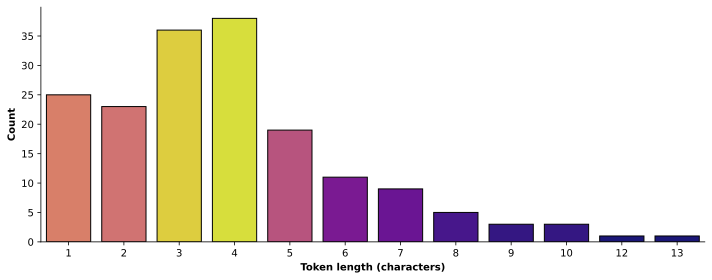

In [8]:
plt.figure(figsize=(10,4))

sns.barplot(x=val_counts.index, y=val_counts.values, edgecolor='k', hue=val_counts.values, palette='plasma', legend=False)

plt.gca().set(xlabel='Token length (characters)', ylabel='Count')

plt.tight_layout()
plt.savefig('ch2_proj3_part1.png')
plt.show()

In [9]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


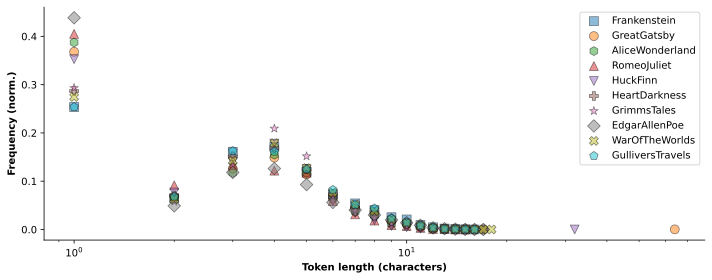

In [10]:
plt.figure(figsize=(10,4))

markersymbols = 'soh^vP*DXp'

for i, (code, title) in enumerate(bookurls):
    fullurl = baseurl + code + '/pg' + code + '.txt'
    tokens = tokenizer.encode(requests.get(fullurl).text)

    token_lens = [len(tokenizer.decode(t)) for t in tokens]
    df = pd.DataFrame({'token':tokens, 'length':token_lens})
    val_counts = df['length'].value_counts(normalize=True)
    sns.scatterplot(x      = val_counts.index,
                    y      = val_counts.values,
                    s      = 80,
                    alpha  = .5,
                    marker = markersymbols[i],
                    edgecolor = 'k',
                    label  = title)
plt.gca().set(xlabel='Token length (characters)', ylabel='Frequency (norm.)', xscale='log')

plt.tight_layout()
plt.savefig('ch2_proj3_part2.png')
plt.show()